In [1]:
import os
import numpy as np
import joblib
import pandas as pd
import glob
import matplotlib.pyplot as plt
import subprocess

# Paths

In [2]:
main_path = "plink/ref_pca"
eigenallele = f"{main_path}.eigenvec.allele"
plink_exe = "plink/plink1.9.exe"
plink2_exe = "plink/plink2.exe"

# Extract the overlap list from the reference PCA

In [3]:
print("Extracting Reference SNPs -->")
ref = pd.read_csv(eigenallele, delim_whitespace=True)
ref.iloc[:, 1].to_csv("Reference_SNPs.txt", header=False, index=False)
print(f"Saved {len(ref)} reference SNPs to extract.\n")

C:\Users\sindi\AppData\Local\Temp\ipykernel_9880\826380552.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ref = pd.read_csv(eigenallele, delim_whitespace=True)


Extracting Reference SNPs -->


C:\Users\sindi\AppData\Local\Temp\ipykernel_9880\826380552.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  ref = pd.read_csv(eigenallele, delim_whitespace=True)


Saved 540216 reference SNPs to extract.



# Output

In [4]:
output_dir = "dtc_pcs"
os.makedirs(output_dir, exist_ok=True)
dtc_files = glob.glob("23andMe/genome_*.txt")

In [5]:
# Need to cleean the file names

In [6]:
dtc_files

['23andMe\\genome_.txt',
 '23andMe\\genome_christoph.txt',
 '23andMe\\genome_Christophe.txt',
 '23andMe\\genome_Christopher.txt',
 '23andMe\\genome_Frances_Stewart_v4_Full_20200420173116.txt',
 '23andMe\\genome_hu24385B_v3_Full_20181019043936.txt',
 '23andMe\\genome_Jiahao_Huang_Full_20110331130314.txt',
 '23andMe\\genome_Joshua_Yoakem_v5_Full_20250129211749.txt',
 '23andMe\\genome_Simon_Funk_Full_20140330133719.txt',
 '23andMe\\genome_Travis_Jupp_Full_20140928163021.txt']

References for this section:<br>
https://github.com/psbaltar/rawDNA2vcf/blob/master/23andme_to_vcf.py<br>
https://genarchivist.net/showthread.php?pid=45041<br>


In [7]:
for f in dtc_files:
    base_name = os.path.splitext(os.path.basename(f))[0]
    raw_prefix = f"dtc_raw_{base_name}"
    clean_prefix = f"dtc_clean_{base_name}"
    print(f"Found {len(dtc_files)} files")
    # Convert 23andMe files to the same PLINK format as the 1240k dataset
    cmd_convert = [
        plink_exe,
        "--23file", f,
        "--make-bed",
        "--out", raw_prefix
    ]
    try:
        print(f"Processing: {base_name} -->")
        subprocess.run(cmd_convert, check=True, stdout=subprocess.DEVNULL)
    except subprocess.CalledProcessError as e:
        print(f"Error converting {f}: {e}")
        continue

    # Get rid of duplicate enteries
    bim_file = f"{raw_prefix}.bim"
    bim = pd.read_csv(bim_file, sep="\t", header=None, names=["chr", "snp", "cm", "pos", "a1", "a2"])
    
    # Get variants where Allele 1 = Allele 2
    bad_alleles = bim[bim["a1"] == bim["a2"]]["snp"]
    
    # Get duplicate rsIDs
    duplicate_ids = bim[bim.duplicated(subset=["snp"], keep="first")]["snp"]
    
    # Combine and save to list
    bad_snps = pd.concat([bad_alleles, duplicate_ids]).drop_duplicates()
    exclude_file = f"exclude_{base_name}.txt"
    bad_snps.to_csv(exclude_file, index=False, header=False)
    print(f"Found {len(bad_snps)} problematic SNPs (duplicates/identical alleles).")

    # Filter for thr bad SNPs and get the overlap from the 23andMe files
    cmd_filter = [
        plink_exe,
        "--bfile", raw_prefix,
        "--extract", "Reference_SNPs.txt",
        "--exclude", exclude_file,
        "--make-bed",
        "--out", clean_prefix
    ]
    try:
        subprocess.run(cmd_filter, check=True, stdout=subprocess.DEVNULL)
        print("Filtered overlap and removed bad SNPs.")
    except subprocess.CalledProcessError as e:
        print(f"Error filtering {raw_prefix}: {e}")
        continue

    # Fit PCA
    n_pc = 15
    start = 7 # Column of PC1
    end = start + n_pc - 1 # Column of final PC
    pca_output = os.path.join(output_dir, f"{base_name}_pcs")
    
    cmd_pca = [
        plink2_exe,
        "--bfile", clean_prefix,
        "--score", eigenallele, "2", "6","header", "no-mean-imputation",
        "--score-col-nums", f"{start}-{end}",
        "--memory", "2000",
        "--threads", "2",
        "--out", pca_output
    ]
    try:
        subprocess.run(cmd_pca, check=True, stdout=subprocess.DEVNULL)
        print(f"Completed!! Saved to: {pca_output}.sscore\n")
    except subprocess.CalledProcessError as e:
        print(f"Error for {clean_prefix} due to: {e}")

Found 10 files
Processing: genome_ -->
Found 11003 problematic SNPs (duplicates/identical alleles).
Filtered overlap and removed bad SNPs.
Completed!! Saved to: dtc_pcs\genome__pcs.sscore

Found 10 files
Processing: genome_christoph -->
Found 11003 problematic SNPs (duplicates/identical alleles).
Filtered overlap and removed bad SNPs.
Completed!! Saved to: dtc_pcs\genome_christoph_pcs.sscore

Found 10 files
Processing: genome_Christophe -->
Found 11003 problematic SNPs (duplicates/identical alleles).
Filtered overlap and removed bad SNPs.
Completed!! Saved to: dtc_pcs\genome_Christophe_pcs.sscore

Found 10 files
Processing: genome_Christopher -->
Found 11003 problematic SNPs (duplicates/identical alleles).
Filtered overlap and removed bad SNPs.
Completed!! Saved to: dtc_pcs\genome_Christopher_pcs.sscore

Found 10 files
Processing: genome_Frances_Stewart_v4_Full_20200420173116 -->
Found 6809 problematic SNPs (duplicates/identical alleles).
Filtered overlap and removed bad SNPs.
Complete

# Get the PCA


In [8]:
# Paths
eigenval_file = "plink/ref_pca.eigenval"
sscore_dir = "dtc_pcs"
n_output_dir = "dtc_pcs_normalised"
os.makedirs(n_output_dir, exist_ok=True)

In [9]:
# Get the eigenvalues
eig = np.loadtxt(eigenval_file)
print(f"Loaded {len(eig)} eigenvalues")

# Get all the 23andMe samples
sscore_files = glob.glob(os.path.join(sscore_dir, "*.sscore"))


Loaded 15 eigenvalues


In [10]:
for file in sscore_files:

    df = pd.read_csv(file, sep=r"\s+")

    # Normalize each PC
    for i in range(len(eig)):

        score_col = f"SCORE{i+1}_AVG"

        if score_col in df.columns:

            df[f"PC{i+1}"] = df[score_col] / np.sqrt(eig[i])


    keep_cols = ["#FID", "IID"] + [f"PC{i+1}" for i in range(len(eig))]
    keep_cols = [c for c in keep_cols if c in df.columns]

    df_out = df[keep_cols]

    # Save onto a new file
    base = os.path.basename(file).replace(".sscore", "_normalised.csv")
    out_path = os.path.join(n_output_dir, base)

    df_out.to_csv(out_path, index=False)

    print(f"Saved → {out_path}")

print("All PCA files have been normalised.")

Saved → dtc_pcs_normalised\genome_Christopher_pcs_normalised.csv
Saved → dtc_pcs_normalised\genome_Christophe_pcs_normalised.csv
Saved → dtc_pcs_normalised\genome_christoph_pcs_normalised.csv
Saved → dtc_pcs_normalised\genome_Frances_Stewart_v4_Full_20200420173116_pcs_normalised.csv
Saved → dtc_pcs_normalised\genome_hu24385B_v3_Full_20181019043936_pcs_normalised.csv
Saved → dtc_pcs_normalised\genome_Jiahao_Huang_Full_20110331130314_pcs_normalised.csv
Saved → dtc_pcs_normalised\genome_Joshua_Yoakem_v5_Full_20250129211749_pcs_normalised.csv
Saved → dtc_pcs_normalised\genome_Simon_Funk_Full_20140330133719_pcs_normalised.csv
Saved → dtc_pcs_normalised\genome_Travis_Jupp_Full_20140928163021_pcs_normalised.csv
Saved → dtc_pcs_normalised\genome__pcs_normalised.csv
All PCA files have been normalised.


In [11]:
pca_path = glob.glob("dtc_pcs_normalised/genome_*normalised.csv")
all_dfs = []

for f in pca_path:
    filename = os.path.basename(f)
    
    parts = filename.split("_")
    name_extracted = f"{parts[1]}_{parts[2]}"
    
    temp_df = pd.read_csv(f, sep=r',')
    temp_df.insert(0, "Name", name_extracted)
    
    all_dfs.append(temp_df)

pca = pd.concat(all_dfs, ignore_index=True)
pca.head(10)

,Name,#FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
0,Christopher_pcs,FAM001,ID001,0.005026,0.003033,0.002166,-0.000945,0.002258,0.001537,-0.001993,-0.001390,-0.006777,-0.000425,-0.010432,0.007471,0.001597,-0.004157,-0.003604
1,Christophe_pcs,FAM001,ID001,0.005026,0.003033,0.002166,-0.000945,0.002258,0.001537,-0.001993,-0.001390,-0.006777,-0.000425,-0.010432,0.007471,0.001597,-0.004157,-0.003604
2,christoph_pcs,FAM001,ID001,0.005026,0.003033,0.002166,-0.000945,0.002258,0.001537,-0.001993,-0.001390,-0.006777,-0.000425,-0.010432,0.007471,0.001597,-0.004157,-0.003604
3,Frances_Stewart,FAM001,ID001,0.004262,0.000621,0.000164,0.000119,0.000863,-0.000253,-0.001416,-0.002961,-0.004082,-0.000749,-0.009133,0.006889,0.000270,-0.001993,-0.000843
4,hu24385B_v3,FAM001,ID001,0.006997,0.000683,-0.000278,0.001347,0.000464,-0.000449,-0.001356,-0.004336,-0.002114,-0.001199,-0.011025,0.006072,-0.002253,-0.000863,-0.000996
5,Jiahao_Huang,FAM001,ID001,0.006493,-0.008016,-0.004446,-0.001622,-0.001525,0.000805,-0.000470,-0.006187,-0.001762,0.003953,-0.008407,0.003593,-0.003665,-0.000415,-0.000122
6,Joshua_Yoakem,FAM001,ID001,0.004915,0.003000,0.002133,-0.000946,0.002801,0.001450,-0.002817,-0.001182,-0.007282,0.000116,-0.010004,0.006691,0.001876,-0.003511,-0.003422
7,Simon_Funk,FAM001,ID001,0.005056,0.000499,0.000230,0.001014,0.000419,-0.000272,-0.001242,-0.003172,-0.002656,-0.000963,-0.009816,0.006252,-0.001432,-0.000953,-0.000277
8,Travis_Jupp,FAM001,ID001,0.004304,-0.001320,0.002580,-0.000111,0.000109,-0.000417,-0.000885,-0.004027,-0.004239,0.000536,-0.008130,0.008616,-0.002100,-0.001823,-0.000987
9,_pcs,FAM001,ID001,0.005026,0.003033,0.002166,-0.000945,0.002258,0.001537,-0.001993,-0.001390,-0.006777,-0.000425,-0.010432,0.007471,0.001597,-0.004157,-0.003604


# Exploratory Evaluation

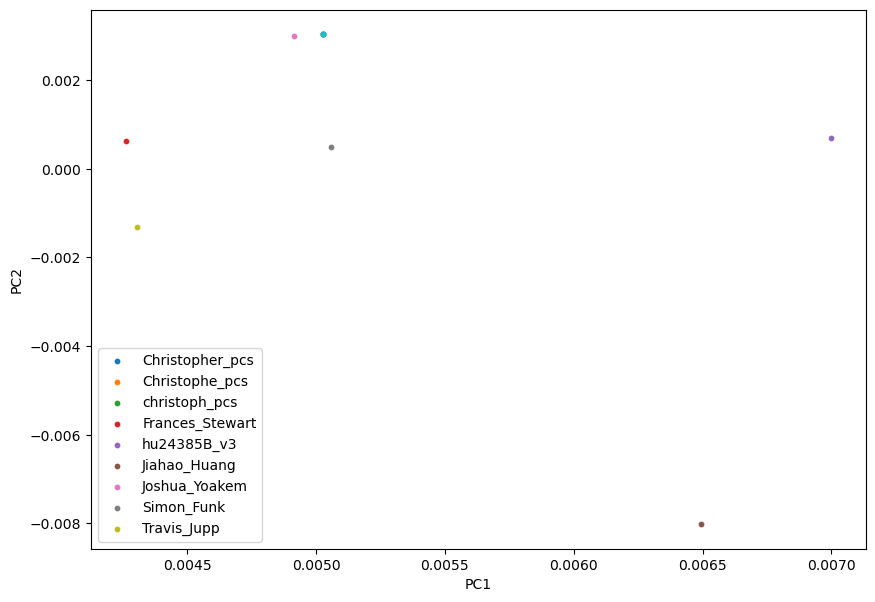

In [12]:
plt.figure(figsize=(10,7))
for pop in pca["Name"].unique():
    sub = pca[pca["Name"]==pop]
    plt.scatter(sub["PC1"],sub["PC2"], label=pop, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()